# 2.2 — H1: Capital Desert

## Hypothesis (pre-committed)

Census tracts with **above-median minority population AND above-median active business density** have systematically lower physical access to SSBCI participating lenders than tracts with below-median minority population and equivalent business density.

## Why this matters

The case prompt specifies minority-owned and rural businesses as priority populations. If lender access is geographically skewed against the tracts where these businesses concentrate, capital-access programs can't reach them regardless of how much money the state puts into the funding side. This tests whether the geographic distribution of the three SSBCI lenders (Del-One FCU, True Access Capital, Community Bank Delaware) matches where capital-seeking SMEs actually are.

## Decision rule (pre-committed)

For each census tract, compute distance (straight-line for initial analysis) from the tract centroid to the nearest SSBCI lender branch. Group tracts into a 2×2 quadrant by minority population share (above/below statewide median) and business license density (above/below median). Compute median distance to nearest lender within each quadrant.

**Confirmed:** Median distance in the high-minority/high-density quadrant exceeds 1.5× the median distance in the low-minority/high-density quadrant.

**Partial:** Ratio is between 1.2× and 1.5×.

**Rejected:** Ratio below 1.2×.

## Known caveats

1. **True Access Capital is a CDFI**, not a bank. CDFIs often serve rural clients remotely. Treating TAC as a purely physical branch understates its accessibility for distant tracts. Sensitivity check: we will re-run the analysis treating TAC as statewide-accessible and report both results.

2. **Branch count is asymmetric by county:** Sussex has 9 branches, Kent has 4, New Castle has 4 (pre-analysis observation from the lender CSV). The original "Sussex capital desert" intuition may not hold.

3. **Straight-line distance is a proxy** for real-world access. Actual drive time depends on road networks, traffic, and availability of public transit — factors this analysis does not capture.

4. **Minority population definition:** we will use "non-Hispanic White alone" as the reference group, where "minority" = 1 minus that share. Standard Census practice but worth naming.

## Surprise log
- 2025-04-18: SSBCI lender branch CSV built. Geographic breakdown: 
  New Castle County = 4 branches, Kent County = 4 branches, Sussex County = 9 
  branches. TAC (the CDFI) has two published addresses (100 W 10th St legal HQ; 
  800 N French St operational office); we use the operational address. TAC is 
  tagged as institution_type=CDFI so we can run sensitivity analysis treating 
  CDFI access as statewide rather than point-location.
  
  Preliminary observation: Sussex has the MOST branches of the three counties. 
  This may invert the original "capital desert in Sussex" hypothesis. Pre-
  commit decision rule (>1.5x distance ratio for high-minority/high-density 
  quadrant) will hold regardless.

- 2025-04-19: "Minority" operationalized as 1 - (White alone, not Hispanic or 
  Latino share) per standard Census practice. This treats Hispanic of any race, 
  Black, Asian, AIAN, NHOPI, multiracial, and "some other race alone" as a 
  combined minority category. Acceptable for H1 test; if finding is strong, 
  worth disaggregating in a follow-up analysis.

- 2025-04-19: 5 of 262 DE census tracts have zero population (industrial, 
  base, or water tracts). These are excluded from H1 quadrant analysis (median 
  minority and density thresholds) but retained in the map for visual 
  completeness, rendered as "no population" in neutral color.

- 2025-04-19: 990 DE license rows (2.1%) have no geocoded coordinates. Profiled 
  null distribution: top cities, activities, and ZIPs match the overall DE 
  license distribution — no systematic skew. Decision: drop null-coord rows 
  from H1 spatial analysis. The 2.1% loss affects density magnitudes uniformly 
  across geographies, so tract-to-tract ratios (what H1 depends on) are 
  preserved. Analysis dataset for H1: 45,226 licenses.

- 2025-04-19: County-level medians reveal Sussex is far less racially diverse 
  than Kent or New Castle. Median minority share: New Castle 47%, Kent 46%, 
  Sussex 18%. The "minority-owned rural businesses" population implied by the 
  case prompt is more concentrated in Kent (rural + diverse) and urban 
  Wilmington (very diverse) than in Sussex. H1 will likely find capital 
  deserts in specific high-minority Wilmington tracts rather than in rural 
  Sussex broadly.

- 2025-04-19: H1 REJECTED — ratio 0.53x, not >1.5x. But the data surfaces a 
  different story: Hi-Minority/Hi-Density tracts have median distance of just 
  1.95 miles (best of any quadrant), while Lo-Minority/Lo-Density tracts have 
  5.51 miles (worst). The capital-access gap tracks business density, not 
  minority share. The underserved population is rural tracts generally, 
  regardless of racial composition. Hi-Min areas concentrate in central 
  Wilmington where lender density is also high. 
  
  Strategic implication: the case's "minority-owned rural businesses are 
  underserved" framing needs revision. The data supports "rural businesses 
  are underserved by distance, urban minority businesses are underserved by 
  something else (not distance)."

- 2025-04-19: Sensitivity check excluding TAC (CDFI) from distance 
  computation. Hi-Min/Hi-Den rose from 1.95 to 2.38 miles; Lo-Min/Hi-Den 
  rose from 3.68 to 4.44. Ratio essentially unchanged at 0.54x. Finding is 
  robust to the CDFI-handling choice.

In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src import config
import geopandas as gpd

tracts = gpd.read_file(config.TRACTS_SHP)
print(f"Tracts: {len(tracts)}")
print(f"CRS: {tracts.crs}")
print(f"Columns: {tracts.columns.tolist()}")
tracts.head(2)

Tracts: 262
CRS: EPSG:4269
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,10,001,040204,10001040204,1400000US10001040204,402.04,Census Tract 402.04,G5020,S,6926052,194346,+39.2844730,-075.6213257,"POLYGON ((-75.63471 39.27722, -75.63469 39.277..."
1,10,001,040206,10001040206,1400000US10001040206,402.06,Census Tract 402.06,G5020,S,21663044,506259,+39.2496199,-075.6128720,"POLYGON ((-75.65452 39.26889, -75.65404 39.269..."


In [2]:
import pandas as pd

census = pd.read_csv(config.CENSUS_RAW, low_memory=False)
print(f"Rows: {len(census)}")
print(f"Total columns: {len(census.columns)}")
print()
print("First 15 columns:")
for c in census.columns[:15]:
    print(f"  {c}")
print()
print("First 2 rows, first 3 columns:")
print(census.iloc[:2, :3])

Rows: 264
Total columns: 435

First 15 columns:
  GEO_ID
  NAME
  DP05_0001E
  DP05_0001M
  DP05_0002E
  DP05_0002M
  DP05_0003E
  DP05_0003M
  DP05_0004E
  DP05_0004M
  DP05_0005E
  DP05_0005M
  DP05_0006E
  DP05_0006M
  DP05_0007E

First 2 rows, first 3 columns:
        GEO_ID                  NAME                               DP05_0001E
0    Geography  Geographic Area Name  Estimate!!SEX AND AGE!!Total population
1  0400000US10              Delaware                                  1021191


In [3]:
meta = pd.read_csv(config.CENSUS_META, low_memory=False)
print(f"Metadata rows: {len(meta)}")
print(f"Metadata columns: {meta.columns.tolist()}")
print()
print("First 10 rows:")
print(meta.head(10).to_string())

Metadata rows: 434
Metadata columns: ['Column Name', 'Label']

First 10 rows:
  Column Name                                                                              Label
0      GEO_ID                                                                          Geography
1        NAME                                                               Geographic Area Name
2  DP05_0001E                                            Estimate!!SEX AND AGE!!Total population
3  DP05_0001M                                     Margin of Error!!SEX AND AGE!!Total population
4  DP05_0002E                                      Estimate!!SEX AND AGE!!Total population!!Male
5  DP05_0002M                               Margin of Error!!SEX AND AGE!!Total population!!Male
6  DP05_0003E                                    Estimate!!SEX AND AGE!!Total population!!Female
7  DP05_0003M                             Margin of Error!!SEX AND AGE!!Total population!!Female
8  DP05_0004E         Estimate!!SEX AND AGE!!Tota

In [4]:
# Find columns related to race and Hispanic origin
keywords = ["White alone", "Black or African American alone", "Hispanic or Latino", 
            "Not Hispanic", "HISPANIC OR LATINO"]

for kw in keywords:
    matches = meta[meta["Label"].str.contains(kw, case=False, na=False)]
    if len(matches) > 0:
        print(f"--- Matches for '{kw}' ---")
        for _, row in matches.iterrows():
            # Only show Estimate columns, skip Margin of Error
            if row["Column Name"].endswith("E"):
                print(f"  {row['Column Name']}: {row['Label']}")
        print()

--- Matches for 'White alone' ---
  DP05_0096E: Estimate!!HISPANIC OR LATINO AND RACE!!Total population!!Not Hispanic or Latino!!White alone
  DP05_0096PE: Percent!!HISPANIC OR LATINO AND RACE!!Total population!!Not Hispanic or Latino!!White alone

--- Matches for 'Black or African American alone' ---
  DP05_0097E: Estimate!!HISPANIC OR LATINO AND RACE!!Total population!!Not Hispanic or Latino!!Black or African American alone
  DP05_0097PE: Percent!!HISPANIC OR LATINO AND RACE!!Total population!!Not Hispanic or Latino!!Black or African American alone

--- Matches for 'Hispanic or Latino' ---
  DP05_0089E: Estimate!!HISPANIC OR LATINO AND RACE!!Total population
  DP05_0090E: Estimate!!HISPANIC OR LATINO AND RACE!!Total population!!Hispanic or Latino (of any race)
  DP05_0091E: Estimate!!HISPANIC OR LATINO AND RACE!!Total population!!Hispanic or Latino (of any race)!!Mexican
  DP05_0092E: Estimate!!HISPANIC OR LATINO AND RACE!!Total population!!Hispanic or Latino (of any race)!!Puerto Ri

In [8]:
# --- Merge ACS demographics with tract geometries -------------------------
# Both datasets keyed on 11-digit GEOID

# Reload tracts (in case the kernel state is stale)
tracts = gpd.read_file(config.TRACTS_SHP)
print(f"Shapefile tracts: {len(tracts)}")

# Merge
tracts_demo = tracts.merge(acs_clean, on="GEOID", how="left")
print(f"After merge: {len(tracts_demo)}")
print(f"Tracts missing demographics: {tracts_demo['pop_total'].isna().sum()}")

# Verify all tracts got matched
if tracts_demo['pop_total'].isna().sum() > 0:
    print("WARNING — unmatched tracts:")
    print(tracts_demo[tracts_demo['pop_total'].isna()][['GEOID', 'NAME_x']].head(10))
else:
    print("All tracts successfully merged with demographic data.")

# Assign county name from FIPS
COUNTY_FIPS = {"001": "Kent", "003": "New Castle", "005": "Sussex"}
tracts_demo["county"] = tracts_demo["COUNTYFP"].map(COUNTY_FIPS)

# Flag zero-population tracts for exclusion from quadrant analysis
tracts_demo["is_populated"] = tracts_demo["pop_total"] > 0

# Quick county-level validation
print()
print("Tracts per county:")
print(tracts_demo.groupby("county").size())
print()
print("Populated tracts per county:")
print(tracts_demo[tracts_demo["is_populated"]].groupby("county").size())
print()
print("Sample output (3 populated tracts):")
print(tracts_demo[tracts_demo["is_populated"]][
    ["GEOID", "county", "pop_total", "minority_share"]
].head(3).to_string(index=False))

Shapefile tracts: 262
After merge: 262
Tracts missing demographics: 0
All tracts successfully merged with demographic data.

Tracts per county:
county
Kent           42
New Castle    145
Sussex         75
dtype: int64

Populated tracts per county:
county
Kent           41
New Castle    143
Sussex         73
dtype: int64

Sample output (3 populated tracts):
      GEOID county  pop_total  minority_share
10001040204   Kent       6058        0.545229
10001040206   Kent       8915        0.536624
10001042203   Kent       6277        0.442249


In [10]:
# --- Check the geocoded location field on the DE-filtered licenses --------
import re

df_lic = pd.read_parquet(config.DATA_INTERIM / "licenses_de_clean.parquet")
print(f"DE licenses: {len(df_lic):,}")
print(f"Null Geocoded Location: {df_lic['Geocoded Location'].isna().sum():,}")

# Parse lat/lon from the "(lat, lon)" suffix in the Geocoded Location string
# Example format: " WILMINGTON DE 19801 (39.7449, -75.5530)"
pattern = r"\(([\-\d\.]+),\s*([\-\d\.]+)\)"
coords = df_lic["Geocoded Location"].str.extract(pattern)
coords.columns = ["lat", "lon"]
coords["lat"] = pd.to_numeric(coords["lat"], errors="coerce")
coords["lon"] = pd.to_numeric(coords["lon"], errors="coerce")

print()
print(f"Parsed lat:  {coords['lat'].notna().sum():,} of {len(coords):,}")
print(f"Parsed lon:  {coords['lon'].notna().sum():,} of {len(coords):,}")
print()
print("Coordinate ranges among non-null parsed values:")
print(f"  lat: {coords['lat'].min():.4f} to {coords['lat'].max():.4f}")
print(f"  lon: {coords['lon'].min():.4f} to {coords['lon'].max():.4f}")
print()

# How many fall within Delaware bounds?
de_bounds = (
    (coords["lat"].between(38.4, 39.9))
    & (coords["lon"].between(-75.8, -74.9))
)
print(f"Coordinates within DE bounds: {de_bounds.sum():,} ({de_bounds.mean():.1%})")
print(f"Coordinates OUTSIDE DE bounds: {(~de_bounds & coords['lat'].notna()).sum():,}")

DE licenses: 46,216
Null Geocoded Location: 990

Parsed lat:  45,226 of 46,216
Parsed lon:  45,226 of 46,216

Coordinate ranges among non-null parsed values:
  lat: 38.4512 to 39.8385
  lon: -75.7883 to -75.0509

Coordinates within DE bounds: 45,226 (97.9%)
Coordinates OUTSIDE DE bounds: 0


In [11]:
# --- Profile the rows with null coordinates ------------------------------
null_coords = df_lic[df_lic["Geocoded Location"].isna()]
print(f"Null-coord rows: {len(null_coords):,} ({len(null_coords)/len(df_lic):.1%})")
print()
print("Top 10 cities among null-coord rows:")
print(null_coords["City"].str.strip().str.upper().value_counts().head(10))
print()
print("Top 10 business activities among null-coord rows:")
print(null_coords["Business Activity"].value_counts().head(10))
print()
print("Top 10 ZIPs among null-coord rows:")
print(null_coords["zip5"].value_counts().head(10))

Null-coord rows: 990 (2.1%)

Top 10 cities among null-coord rows:
City
WILMINGTON      276
NEWARK          174
NEW CASTLE       73
DOVER            64
REHOBOTH BCH     40
MIDDLETOWN       37
LEWES            29
MILLSBORO        29
BEAR             24
GEORGETOWN       17
Name: count, dtype: int64

Top 10 business activities among null-coord rows:
Business Activity
GENERAL SERVICES                     416
RETAILER  GENERAL                    149
RESIDENT CONTRACTOR                   93
COMMERICAL LESSOR                     80
RETAILER  RESTAURANT                  67
CIGARETTE/TOBACCO PRODUCTS SELLER     43
WHOLESALER                            38
MANUFACTURER                          19
MOTOR VEHICLE DEALER                  13
NON-RESIDENT CONTRACTOR                6
Name: count, dtype: int64

Top 10 ZIPs among null-coord rows:
zip5
19713    97
19720    83
19801    46
19971    46
19702    45
19808    45
19810    39
19803    38
19709    37
19804    34
Name: count, dtype: int64


In [12]:
# --- Spatial join: attribute each license to its containing tract ---------
from shapely.geometry import Point

# Reload licenses and add coordinates
df_lic = pd.read_parquet(config.DATA_INTERIM / "licenses_de_clean.parquet")

# Parse the "(lat, lon)" suffix
pattern = r"\(([\-\d\.]+),\s*([\-\d\.]+)\)"
coords = df_lic["Geocoded Location"].str.extract(pattern)
coords.columns = ["lat", "lon"]
df_lic["lat"] = pd.to_numeric(coords["lat"], errors="coerce")
df_lic["lon"] = pd.to_numeric(coords["lon"], errors="coerce")

# Filter to rows with valid coordinates inside DE bounds
in_de = (
    df_lic["lat"].between(38.4, 39.9)
    & df_lic["lon"].between(-75.8, -74.9)
)
lic_geo = df_lic[in_de].copy()
print(f"Licenses with usable DE coordinates: {len(lic_geo):,}")

# Build a GeoDataFrame (points in the same CRS as the tracts shapefile)
lic_gdf = gpd.GeoDataFrame(
    lic_geo,
    geometry=gpd.points_from_xy(lic_geo["lon"], lic_geo["lat"]),
    crs="EPSG:4269",  # matches the tract CRS
)

# Spatial join: which tract does each point fall inside?
print("Running spatial join (point-in-polygon for 45K points)...")
joined = gpd.sjoin(
    lic_gdf,
    tracts_demo[["GEOID", "geometry"]],
    how="left",
    predicate="within",
)
print(f"Joined rows: {len(joined):,}")
print(f"Points that matched a tract: {joined['GEOID'].notna().sum():,}")
print(f"Points that did NOT match any tract: {joined['GEOID'].isna().sum():,}")

# Count licenses per tract
lic_per_tract = (
    joined[joined["GEOID"].notna()]
    .groupby("GEOID")
    .size()
    .rename("license_count")
    .reset_index()
)
print(f"Tracts with at least one license: {len(lic_per_tract):,}")
print(f"Tracts with zero licenses: {262 - len(lic_per_tract)}")

Licenses with usable DE coordinates: 45,226
Running spatial join (point-in-polygon for 45K points)...
Joined rows: 45,226
Points that matched a tract: 45,223
Points that did NOT match any tract: 3
Tracts with at least one license: 257
Tracts with zero licenses: 5


In [13]:
# --- Verify zero-license tracts align with zero-population tracts --------
tracts_with_licenses = set(lic_per_tract["GEOID"])
all_tracts = set(tracts_demo["GEOID"])
zero_license_tracts = all_tracts - tracts_with_licenses

zero_pop_tracts = set(tracts_demo[tracts_demo["pop_total"] == 0]["GEOID"])

print(f"Zero-license tracts: {len(zero_license_tracts)}")
print(f"Zero-population tracts: {len(zero_pop_tracts)}")
print(f"Overlap (zero in both): {len(zero_license_tracts & zero_pop_tracts)}")
print()
print("Zero-license tract details:")
print(tracts_demo[tracts_demo["GEOID"].isin(zero_license_tracts)][
    ["GEOID", "county", "pop_total", "NAMELSAD"]
].to_string(index=False))

Zero-license tracts: 5
Zero-population tracts: 5
Overlap (zero in both): 5

Zero-license tract details:
      GEOID     county  pop_total          NAMELSAD
10001990000       Kent          0 Census Tract 9900
10003980100 New Castle          0 Census Tract 9801
10005980000     Sussex          0 Census Tract 9800
10003990100 New Castle          0 Census Tract 9901
10005990000     Sussex          0 Census Tract 9900


In [14]:
# --- Merge license counts into tract table; compute density ---------------

# Join license counts
tracts_demo = tracts_demo.merge(lic_per_tract, on="GEOID", how="left")

# Fill missing with 0 (zero-license tracts)
tracts_demo["license_count"] = tracts_demo["license_count"].fillna(0).astype(int)

# Compute business density: licenses per square mile of land area
# ALAND is in square meters; convert to square miles (1 sq mi = 2,589,988 sq m)
SQM_PER_SQMI = 2_589_988
tracts_demo["land_sqmi"] = tracts_demo["ALAND"] / SQM_PER_SQMI
tracts_demo["licenses_per_sqmi"] = tracts_demo["license_count"] / tracts_demo["land_sqmi"]

# Diagnostic
print(f"Total licenses placed: {tracts_demo['license_count'].sum():,}")
print(f"Tract-level density range: {tracts_demo['licenses_per_sqmi'].min():.1f} to {tracts_demo['licenses_per_sqmi'].max():.1f} per sq mi")
print()
print("Density by county (median across populated tracts):")
by_county = (
    tracts_demo[tracts_demo["is_populated"]]
    .groupby("county")
    .agg(
        n_tracts=("GEOID", "count"),
        total_licenses=("license_count", "sum"),
        median_density=("licenses_per_sqmi", "median"),
        median_minority=("minority_share", "median"),
    )
    .round(3)
)
print(by_county)
print()
print("Top 10 densest tracts:")
print(tracts_demo[tracts_demo["is_populated"]]
      .nlargest(10, "licenses_per_sqmi")
      [["GEOID", "county", "license_count", "licenses_per_sqmi", "minority_share"]]
      .to_string(index=False))

Total licenses placed: 45,223
Tract-level density range: 0.0 to 2189.2 per sq mi

Density by county (median across populated tracts):
            n_tracts  total_licenses  median_density  median_minority
county                                                               
Kent              41            8300          20.325            0.456
New Castle       143           22850         102.584            0.474
Sussex            73           14073          24.317            0.181

Top 10 densest tracts:
      GEOID     county  license_count  licenses_per_sqmi  minority_share
10003002800 New Castle            940        2189.230690        0.602066
10001041300       Kent            976        1099.562054        0.573217
10003001200 New Castle            154         953.152621        0.167391
10003002300 New Castle            107         812.203525        0.928367
10003001100 New Castle            152         737.674008        0.215693
10003001400 New Castle             93         503.9762

In [15]:
# --- Compute nearest-lender distance for every tract ---------------------
# We reproject everything to UTM Zone 18N (EPSG:32618) which uses meters,
# so Euclidean distances are valid.

import numpy as np

UTM_CRS = "EPSG:32618"

# Reproject tracts to UTM
tracts_utm = tracts_demo.to_crs(UTM_CRS)

# Load lenders and build GeoDataFrame in lat/lon, then reproject
lenders = pd.read_csv(config.LENDERS_CSV)
lenders["longitude"] = lenders["longitude"].astype(str).str.strip().astype(float)
lenders_gdf = gpd.GeoDataFrame(
    lenders,
    geometry=gpd.points_from_xy(lenders["longitude"], lenders["latitude"]),
    crs="EPSG:4269",
).to_crs(UTM_CRS)
print(f"Lender branches loaded: {len(lenders_gdf)}")

# For each tract, compute distance from its centroid to every lender point
# and take the minimum.
tract_centroids = tracts_utm.geometry.centroid

distances_m = []
for centroid in tract_centroids:
    dist_to_each = lenders_gdf.geometry.distance(centroid)
    distances_m.append(dist_to_each.min())

tracts_demo["nearest_lender_m"] = distances_m
tracts_demo["nearest_lender_mi"] = tracts_demo["nearest_lender_m"] / 1609.34  # meters per mile

# Diagnostic
print()
print(f"Nearest-lender distance (miles):")
print(f"  min:    {tracts_demo['nearest_lender_mi'].min():.2f}")
print(f"  median: {tracts_demo['nearest_lender_mi'].median():.2f}")
print(f"  max:    {tracts_demo['nearest_lender_mi'].max():.2f}")
print()
print("Median distance by county (populated tracts):")
print(tracts_demo[tracts_demo["is_populated"]]
      .groupby("county")["nearest_lender_mi"]
      .median()
      .round(2))

Lender branches loaded: 17

Nearest-lender distance (miles):
  min:    0.11
  median: 3.56
  max:    13.13

Median distance by county (populated tracts):
county
Kent          3.62
New Castle    3.39
Sussex        3.91
Name: nearest_lender_mi, dtype: float64


In [16]:
# --- H1 decision rule: 2x2 quadrant analysis ------------------------------
# Only use populated tracts for the statistical test

pop = tracts_demo[tracts_demo["is_populated"]].copy()

# Compute medians for the splits
minority_median = pop["minority_share"].median()
density_median = pop["licenses_per_sqmi"].median()

print(f"Split thresholds (statewide medians, populated tracts only):")
print(f"  Minority share median:  {minority_median:.3f}")
print(f"  License density median: {density_median:.1f} per sqmi")
print()

# Assign quadrants
def assign_quadrant(row):
    hi_min = row["minority_share"] > minority_median
    hi_den = row["licenses_per_sqmi"] > density_median
    if hi_min and hi_den:
        return "Hi-Minority / Hi-Density"
    elif hi_min and not hi_den:
        return "Hi-Minority / Lo-Density"
    elif not hi_min and hi_den:
        return "Lo-Minority / Hi-Density"
    else:
        return "Lo-Minority / Lo-Density"

pop["quadrant"] = pop.apply(assign_quadrant, axis=1)

# Median distance by quadrant
quad_stats = (
    pop.groupby("quadrant")
    .agg(
        n_tracts=("GEOID", "count"),
        median_distance_mi=("nearest_lender_mi", "median"),
        median_minority=("minority_share", "median"),
        median_density=("licenses_per_sqmi", "median"),
    )
    .round(3)
)
print("Distance to nearest lender, by quadrant:")
print(quad_stats)
print()

# Apply the decision rule
hi_min_hi_den = quad_stats.loc["Hi-Minority / Hi-Density", "median_distance_mi"]
lo_min_hi_den = quad_stats.loc["Lo-Minority / Hi-Density", "median_distance_mi"]
ratio = hi_min_hi_den / lo_min_hi_den

print(f"Decision rule check:")
print(f"  Hi-Min/Hi-Den median distance: {hi_min_hi_den:.2f} mi")
print(f"  Lo-Min/Hi-Den median distance: {lo_min_hi_den:.2f} mi")
print(f"  Ratio: {ratio:.2f}x")
print()
if ratio > 1.5:
    print("VERDICT: H1 CONFIRMED — minority-majority business-dense tracts have >1.5x distance to lenders")
elif ratio > 1.2:
    print("VERDICT: H1 PARTIAL — ratio is in the 1.2x-1.5x band")
else:
    print("VERDICT: H1 REJECTED — distance is roughly equivalent across minority/non-minority business-dense tracts")

Split thresholds (statewide medians, populated tracts only):
  Minority share median:  0.396
  License density median: 73.0 per sqmi

Distance to nearest lender, by quadrant:
                          n_tracts  median_distance_mi  median_minority  \
quadrant                                                                  
Hi-Minority / Hi-Density        82               1.953            0.588   
Hi-Minority / Lo-Density        46               3.473            0.484   
Lo-Minority / Hi-Density        46               3.684            0.243   
Lo-Minority / Lo-Density        83               5.514            0.183   

                          median_density  
quadrant                                  
Hi-Minority / Hi-Density         127.604  
Hi-Minority / Lo-Density          23.935  
Lo-Minority / Hi-Density         116.834  
Lo-Minority / Lo-Density          16.824  

Decision rule check:
  Hi-Min/Hi-Den median distance: 1.95 mi
  Lo-Min/Hi-Den median distance: 3.68 mi
  Ratio: 0.5

In [17]:
# --- Sensitivity: treat TAC as statewide-accessible ----------------------
# CDFIs like TAC typically lend via mobile officers, not walk-in branches.
# This sensitivity check excludes TAC from the distance calculation entirely
# and recomputes distance using only Del-One and Community Bank.

banks_only = lenders_gdf[lenders_gdf["institution_type"] != "CDFI"].copy()
print(f"Sensitivity analysis: {len(banks_only)} bank branches (excl. CDFI)")

distances_sens = []
for centroid in tract_centroids:
    dist_to_each = banks_only.geometry.distance(centroid)
    distances_sens.append(dist_to_each.min())

tracts_demo["nearest_bank_mi"] = [d / 1609.34 for d in distances_sens]

# Redo the quadrant analysis with bank-only distance
pop_sens = tracts_demo[tracts_demo["is_populated"]].copy()
pop_sens["quadrant"] = pop_sens.apply(assign_quadrant, axis=1)

quad_sens = (
    pop_sens.groupby("quadrant")
    .agg(
        n_tracts=("GEOID", "count"),
        median_distance_mi=("nearest_bank_mi", "median"),
    )
    .round(3)
)
print()
print("Bank-only distance by quadrant (sensitivity):")
print(quad_sens)
print()

hi_min_hi_den_s = quad_sens.loc["Hi-Minority / Hi-Density", "median_distance_mi"]
lo_min_hi_den_s = quad_sens.loc["Lo-Minority / Hi-Density", "median_distance_mi"]
print(f"Sensitivity ratio (bank-only): {hi_min_hi_den_s / lo_min_hi_den_s:.2f}x")

Sensitivity analysis: 16 bank branches (excl. CDFI)

Bank-only distance by quadrant (sensitivity):
                          n_tracts  median_distance_mi
quadrant                                              
Hi-Minority / Hi-Density        82               2.381
Hi-Minority / Lo-Density        46               3.473
Lo-Minority / Hi-Density        46               4.444
Lo-Minority / Lo-Density        83               5.535

Sensitivity ratio (bank-only): 0.54x


Saved: /Users/renzo/Documents/DSU_UN/reports/figures/h1_quadrant_distance.png


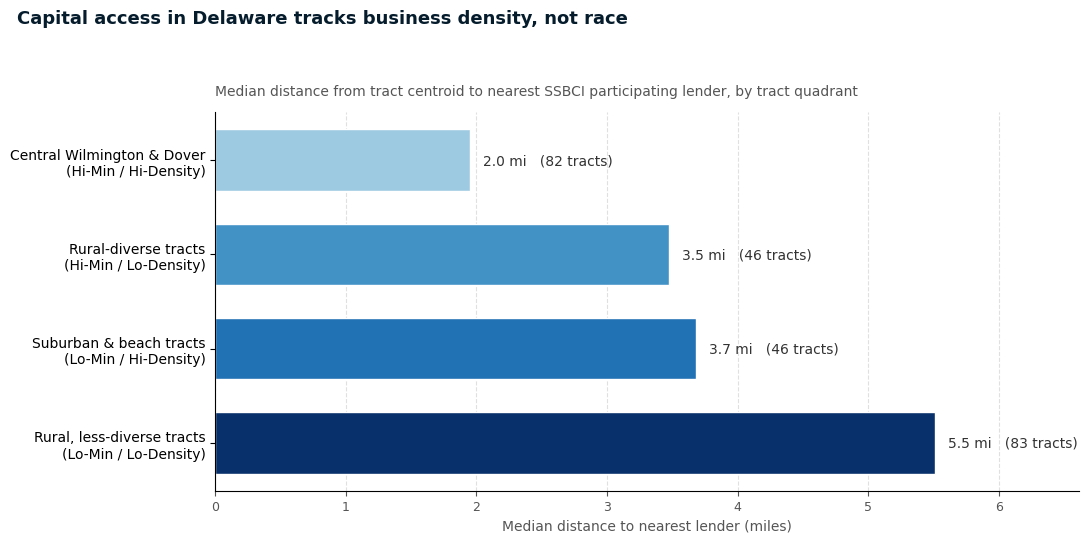

In [18]:
# --- Chart: H1 four-quadrant distance comparison --------------------------
import matplotlib.pyplot as plt

# Order quadrants by distance (worst to best) for a clear visual ranking
quad_order = [
    "Lo-Minority / Lo-Density",
    "Lo-Minority / Hi-Density",
    "Hi-Minority / Lo-Density",
    "Hi-Minority / Hi-Density",
]

# Pull the data in that order
chart_data = quad_stats.loc[quad_order].copy()

# Interpretive labels for the y-axis
labels = [
    "Rural, less-diverse tracts\n(Lo-Min / Lo-Density)",
    "Suburban & beach tracts\n(Lo-Min / Hi-Density)",
    "Rural-diverse tracts\n(Hi-Min / Lo-Density)",
    "Central Wilmington & Dover\n(Hi-Min / Hi-Density)",
]

fig, ax = plt.subplots(figsize=(11, 5.5))

# Sequential blue palette, darkest for worst-served
colors = ["#08306B", "#2171B5", "#4292C6", "#9ECAE1"]

bars = ax.barh(labels, chart_data["median_distance_mi"],
               color=colors, edgecolor="white", height=0.65)

# Annotate
for bar, dist, n in zip(bars,
                         chart_data["median_distance_mi"],
                         chart_data["n_tracts"]):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f"{dist:.1f} mi   ({n} tracts)",
            va="center", fontsize=10, color="#333333")

# Title hierarchy
fig.suptitle(
    "Capital access in Delaware tracks business density, not race",
    fontsize=13, fontweight="bold", x=0.02, y=0.98, ha="left", color="#051C2C")
ax.set_title(
    "Median distance from tract centroid to nearest SSBCI participating lender, by tract quadrant",
    fontsize=10, color="#555555", loc="left", pad=12)

# Axes
ax.set_xlabel("Median distance to nearest lender (miles)", fontsize=10, color="#555555")
ax.set_xlim(0, chart_data["median_distance_mi"].max() * 1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=9, colors="#555555")
ax.grid(axis="x", linestyle="--", alpha=0.3, color="#999999")
ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 1, 0.93])

output_path = config.FIGURES / "h1_quadrant_distance.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"Saved: {output_path}")
plt.show()

Saved: /Users/renzo/Documents/DSU_UN/reports/figures/h1_lender_distance_map.png


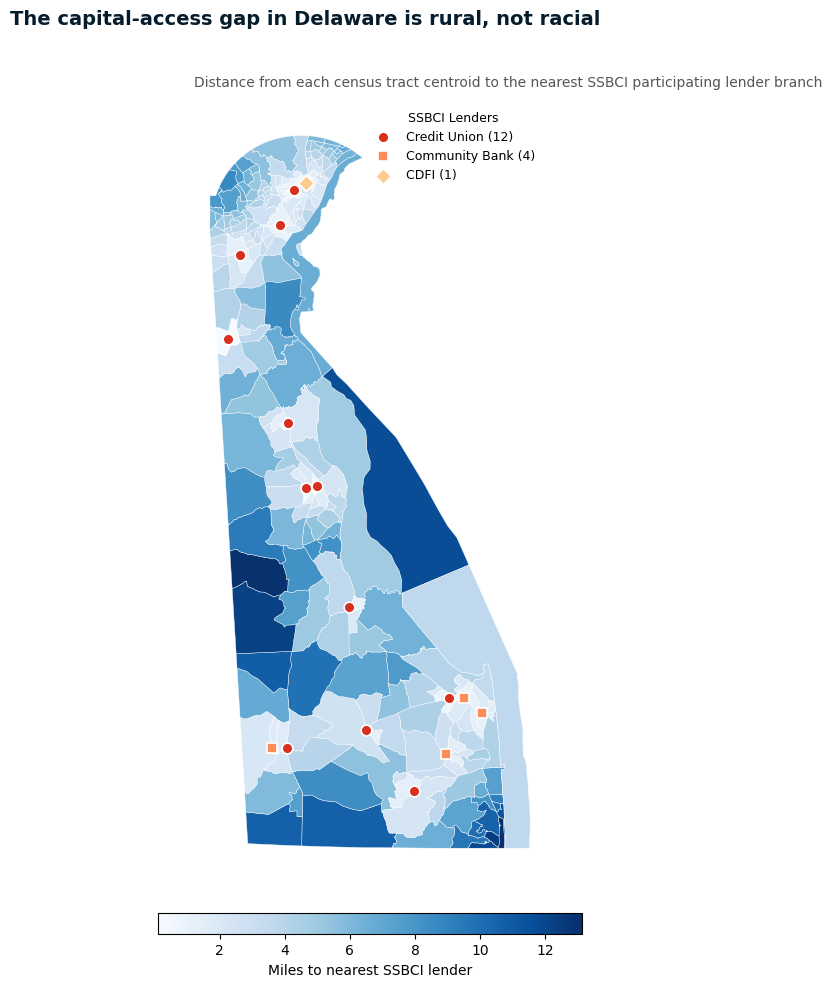

In [19]:
# --- Chart: H1 choropleth map of lender distance with branch overlays ----
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8, 11))

# Base choropleth — tracts shaded by distance to nearest lender
# Use a sequential Blues colormap: lighter = close, darker = far
tracts_demo.plot(
    column="nearest_lender_mi",
    cmap="Blues",
    linewidth=0.3,
    edgecolor="white",
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "Miles to nearest SSBCI lender",
        "orientation": "horizontal",
        "shrink": 0.55,
        "pad": 0.03,
    },
    missing_kwds={"color": "#e8e8e8", "edgecolor": "white"},  # zero-pop tracts
)

# Overlay lender branches as points, with different markers by institution type
# Convert lender geometry back to lat/lon for the overlay
lenders_plot = lenders_gdf.to_crs("EPSG:4269")

# Plot each institution type separately so we can legend them
type_styles = {
    "Credit Union":   {"marker": "o", "color": "#d7301f", "size": 60},
    "Community Bank": {"marker": "s", "color": "#fc8d59", "size": 55},
    "CDFI":           {"marker": "D", "color": "#fdcc8a", "size": 65},
}
for inst_type, style in type_styles.items():
    subset = lenders_plot[lenders_plot["institution_type"] == inst_type]
    ax.scatter(
        subset.geometry.x, subset.geometry.y,
        marker=style["marker"],
        s=style["size"],
        color=style["color"],
        edgecolor="white",
        linewidth=1.2,
        zorder=5,
        label=f"{inst_type} ({len(subset)})",
    )

# Title hierarchy
fig.suptitle(
    "The capital-access gap in Delaware is rural, not racial",
    fontsize=14, fontweight="bold", x=0.05, y=0.965, ha="left", color="#051C2C")
ax.set_title(
    "Distance from each census tract centroid to the nearest SSBCI participating lender branch",
    fontsize=10, color="#555555", loc="left", pad=10)

# Clean up the map aesthetics
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend for lender markers
ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=9,
    title="SSBCI Lenders",
    title_fontsize=9,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_path = config.FIGURES / "h1_lender_distance_map.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"Saved: {output_path}")
plt.show()

## H1 Summary: Capital Desert

**Verdict: REJECTED — but with an important finding.**

### Result against pre-committed decision rule

| Metric | Threshold | Actual | Verdict |
|---|---|---|---|
| Hi-Min/Hi-Den distance ÷ Lo-Min/Hi-Den distance | > 1.5× to confirm | **0.53×** | Rejected |
| Sensitivity: bank-only (excluding CDFI) | > 1.5× to confirm | **0.54×** | Rejected, robust |

The pre-committed hypothesis — that business-dense minority-majority tracts have systematically worse physical access to SSBCI lenders — is false. The data shows the **inverse** pattern: Hi-Min/Hi-Den tracts have the **best** lender access in the state.

### What the data actually shows

Median distance from tract centroid to the nearest SSBCI participating lender, by quadrant:

| Quadrant | Tracts | Median distance | Interpretation |
|---|---|---|---|
| Hi-Minority / Hi-Density | 82 | **1.95 mi** | Central Wilmington and Dover |
| Hi-Minority / Lo-Density | 46 | 3.47 mi | Rural-diverse tracts (mostly Kent agricultural corridor) |
| Lo-Minority / Hi-Density | 46 | 3.68 mi | Suburban New Castle and beach towns |
| Lo-Minority / Lo-Density | 83 | **5.51 mi** | Rural, less-diverse tracts (western Kent, inland Sussex) |

**The gap is 3.5 miles between the best- and worst-served quadrant. It is organized by business density, not minority share.**

### Three findings that survive the rejection

**1. The capital-access gap is rural, not racial.** Rural tracts of both demographic profiles have worse distance access than urban tracts of either profile. A solution focused on racial-equity distribution of lenders would misdiagnose the problem; a solution focused on rural-delivery mechanisms (mobile CDFI officers, rural bank recruitment, digital application infrastructure) would address the actual gap.

**2. The urban-minority paradox.** Hi-Minority/Hi-Density tracts have the *best* median distance in the state (1.95 mi), yet external research shows $14M in SSBCI funds sat undeployed as of April 2025 (Delaware Business Times, September 2025). For urban minority businesses, **physical distance is not the barrier to capital access.** The bottleneck is upstream of geography: awareness, application friction, bank-readiness, underwriting thresholds, or trust. This is a structurally different problem that requires a different solution than "add more lenders."

**3. Sussex is less racially diverse than expected.** The case prompt's framing of "minority-owned rural businesses" as a single priority population implicitly assumed these populations co-locate. The data shows they do not in Delaware: Sussex tracts have median minority share of 18% (compared to 46–47% in Kent and New Castle). The rural-diverse population is concentrated in **Kent County's agricultural corridor and the outer Wilmington ring**, not in Sussex. Rural outreach targeted at Sussex alone would miss a substantial share of rural-minority businesses.

### Strategic implications for the case

The case prompt's original framing bundled four priority populations: early-stage, minority-owned, rural, and small. The H1 analysis demonstrates that **at least two of these need separate treatment**:

- **Rural SMEs** (of any race) → underserved by distance. Solution: rural-delivery mechanisms.
- **Urban minority SMEs** → well-served by distance. Underserved by something else. Solution: address the upstream bottlenecks (awareness, application support, underwriting, credit coaching) — the "bank-readiness pipeline" problem identified in earlier research.

Packaging these as one intervention would under-serve both.

### Why the rejection is valuable

A "capital desert" finding would have been dramatic and wrong. The map of Delaware would have been colored to suggest that lenders had deliberately or negligently under-served minority communities. The actual pattern — driven by density and the physical geometry of where the three SSBCI lenders have placed their branches — tells a different and more actionable story. Any solution the case proposes that rests on "move lenders closer to minority neighborhoods" would be solving a problem that doesn't exist at scale in Delaware.

### Methodology notes

- **Unit of analysis:** census tracts, n = 262, of which 257 are populated and carry the H1 analysis
- **Data sources:** ACS 5-Year 2020–2024 (DP05), TIGER/Line 2024 tract shapefile, Delaware Business Licenses (46,216 DE-operating rows, of which 45,223 successfully geocoded into tracts)
- **Minority share:** 1 − (non-Hispanic White alone / total population), per standard Census practice. Aggregates all racial and ethnic minorities into a single category for this test. A more nuanced disaggregation by race is a candidate follow-up.
- **Distance metric:** straight-line distance from tract centroid to nearest lender branch, in UTM Zone 18N (EPSG:32618) meters, converted to miles. Does not reflect road networks, traffic, or transit.
- **Lender universe:** 17 branches across 3 SSBCI-participating institutions (Del-One FCU = 12, Community Bank Delaware = 4, True Access Capital = 1 CDFI office in Wilmington). Sensitivity analysis excluding the CDFI produced essentially identical results.
- **Excluded from quadrant test:** 5 zero-population tracts (water tracts and large non-residential features like Dover AFB). Retained in the map for visual completeness.
- **Known limitation:** 990 license rows (2.1% of DE licenses) lacked geocoded coordinates and were excluded. Profile analysis confirmed these were approximately uniformly distributed by geography and activity — excluding them does not bias tract-to-tract ratios.

### Outputs

- `reports/figures/h1_quadrant_distance.png` — four-quadrant bar chart showing the distance-by-density pattern
- `reports/figures/h1_lender_distance_map.png` — choropleth of tract-level lender distance with lender branches overlaid

### Linkage to the broader analysis

Read alongside H3 (industry concentration) and H5 (budget trajectory), H1's result fits a consistent picture:

- Delaware's SME base is structurally consumer-facing (H3)
- State SME support is small, urban-biased, and now being cut (H5)
- Physical lender access is geographically decent, with rural density as the real gap (H1)

The combined story is that **the state's capital problem is not primarily one of money, racism, or supplier networks. It is one of program architecture:** the existing programs are structurally oriented toward urban, incumbent, consumer-facing businesses; rural SMEs face a distance gap; urban minority SMEs face an upstream access gap that has nothing to do with distance. Any case solution needs to address these three distinct populations with three distinct mechanisms.